# ARTIFICIAL NEURAL NETWORK: FROM SCRATCH VS TENSORFLOW VALIDATION

## 1. DATA PREPARATION AND VISUALIZATION

### IMPORT LIBRARIES

In [27]:
# ADD PARENT DIRECTORY TO PATH TO IMPORT CUSTOM MODULES
import sys
import os
sys.path.append(os.path.abspath('..'))

# IMPORT STANDARD LIBRARIES
import numpy as np
import matplotlib.pyplot as plt

# IMPORT CUSTOM MODULES
from SRC.UTILS import generate_classification_data, configure_plots
from SRC.PREPROCESSING import StandardScaler, train_test_split
from SRC.LAYERS import Dense
from SRC.ACTIVATIONS import ReLU, Sigmoid, Tanh
from SRC.LOSSES import BinaryCrossEntropy
from SRC.OPTIMIZERS import SGD
from SRC.NEURAL_NETWORK import NeuralNetwork
from SRC.METRICS import accuracy
from EXPERIMENTS.TRAIN_MODEL import train_network

### CONFIGURE MATPLOTLIB TO STRICT REQUIREMENTS

In [28]:
configure_plots()

### GENERATE DATA

In [29]:
DF = generate_classification_data(1000)
X = DF[['FEATURE_1', 'FEATURE_2']].values
Y = DF['TARGET'].values.reshape(-1, 1)

### SPLIT AND SCALE

In [30]:
X_TRAIN, X_TEST, Y_TRAIN, Y_TEST = train_test_split(X, Y, test_size=0.2, seed=36)
SCALER = StandardScaler()
X_TRAIN = SCALER.fit_transform(X_TRAIN)
X_TEST = SCALER.transform(X_TEST)

### PLOT DATA

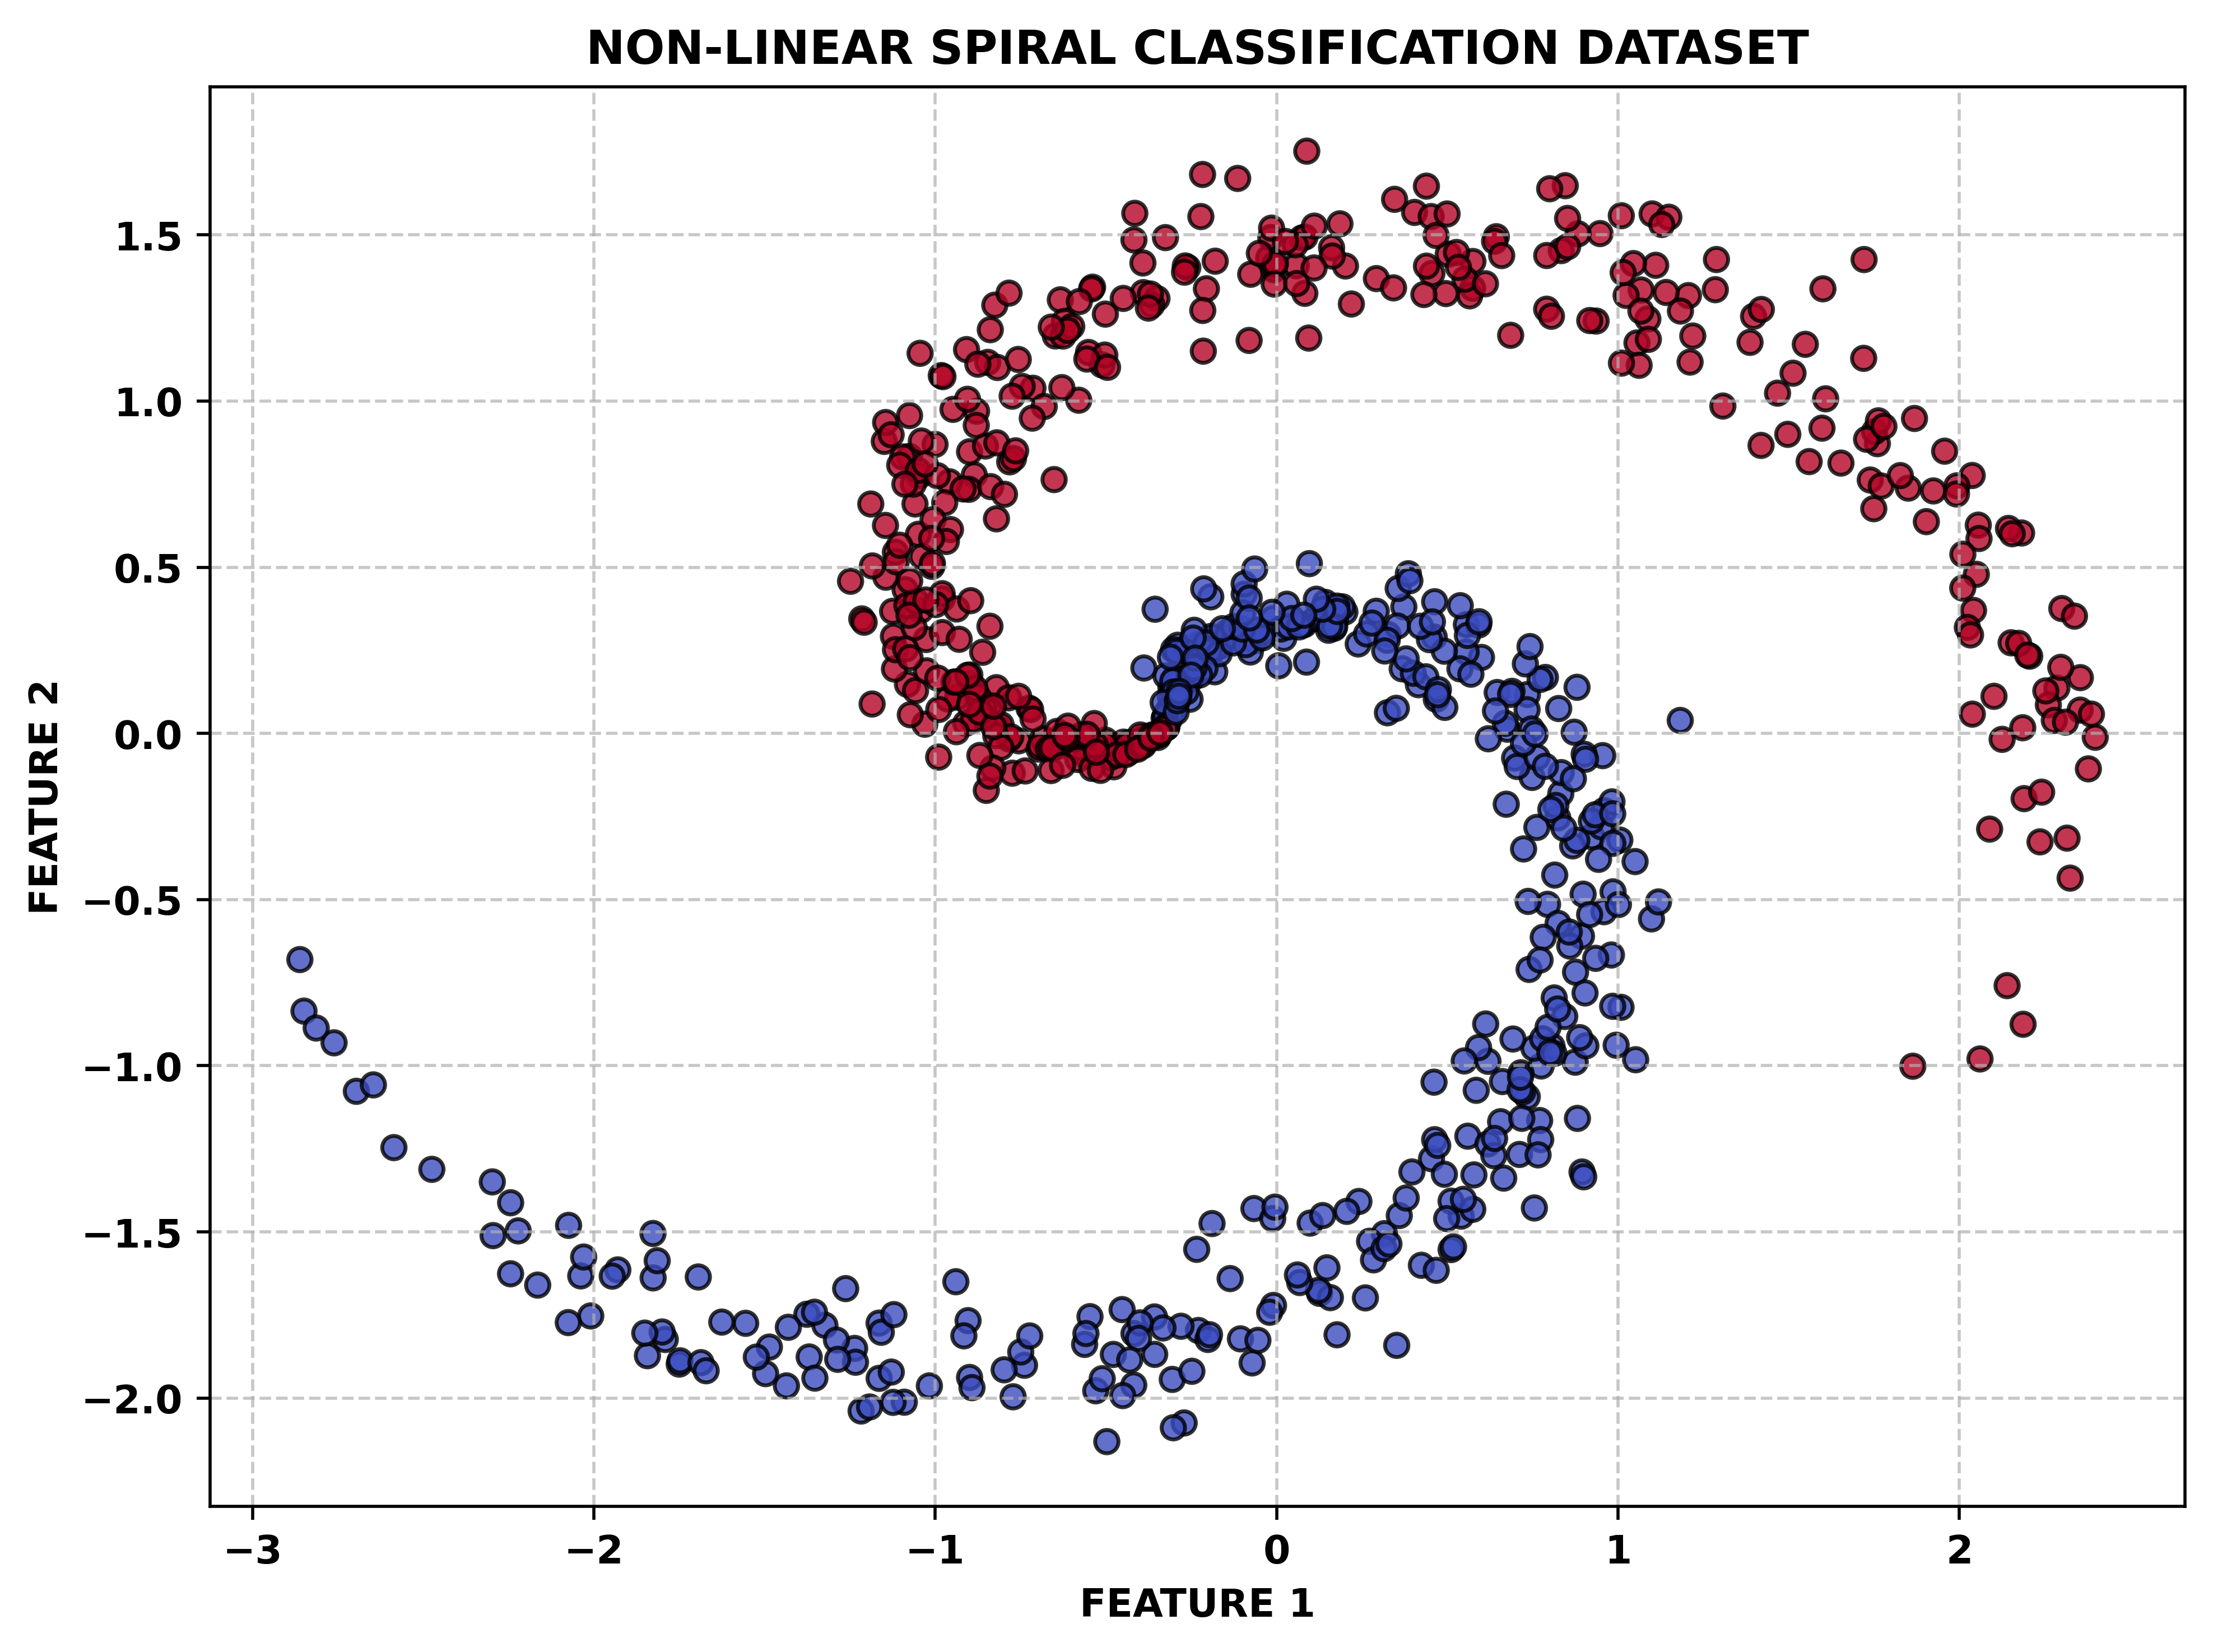

In [31]:
plt.figure(figsize=(8, 6), dpi=500)
plt.scatter(X_TRAIN[:, 0], X_TRAIN[:, 1], c=Y_TRAIN.flatten(), cmap='coolwarm', edgecolors='k', alpha=0.8)
plt.title('NON-LINEAR SPIRAL CLASSIFICATION DATASET', fontweight='bold', fontsize=12)
plt.xlabel('FEATURE 1', fontweight='bold', fontsize=10)
plt.ylabel('FEATURE 2', fontweight='bold', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. TRAINING THE FROM-SCRATCH IMPLEMENTATION

WE INSTANTIATE AND TRAIN OUR CUSTOM, FROM-SCRATCH NEURAL NETWORK USING FIRST PRINCIPLES. 
THE ARCHITECTURE IS A 2-16-16-1 MULTILAYER PERCEPTRON.

### HYPERPARAMETERS

In [32]:
LEARNING_RATE = 0.1
EPOCHS = 150
BATCH_SIZE = 32

### BUILD ARCHITECTURE

In [33]:
# INSTANTIATE CUSTOM MODEL
MODEL_CUSTOM = NeuralNetwork()

MODEL_CUSTOM.add(Dense(n_inputs=2, n_neurons=16, seed=36))
MODEL_CUSTOM.add(ReLU())
MODEL_CUSTOM.add(Dense(n_inputs=16, n_neurons=16, seed=36))
MODEL_CUSTOM.add(ReLU())
MODEL_CUSTOM.add(Dense(n_inputs=16, n_neurons=1, seed=36))
MODEL_CUSTOM.add(Sigmoid())

### COMPILE

In [34]:
MODEL_CUSTOM.compile(loss_function=BinaryCrossEntropy(), optimizer=SGD(learning_rate=LEARNING_RATE))

### TRAIN

In [35]:
print("TRAINING FROM-SCRATCH MODEL...")
HISTORY_CUSTOM = train_network(
    model=MODEL_CUSTOM, 
    X_train=X_TRAIN, 
    y_train=Y_TRAIN, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    metric_fns=[accuracy]
)

TRAINING FROM-SCRATCH MODEL...
EPOCH 001/150 | LOSS: 0.4359 | ACCURACY: 0.6700
EPOCH 010/150 | LOSS: 0.0964 | ACCURACY: 0.9875
EPOCH 020/150 | LOSS: 0.0434 | ACCURACY: 0.9912
EPOCH 030/150 | LOSS: 0.0305 | ACCURACY: 0.9962
EPOCH 040/150 | LOSS: 0.0236 | ACCURACY: 0.9975
EPOCH 050/150 | LOSS: 0.0213 | ACCURACY: 0.9950
EPOCH 060/150 | LOSS: 0.0189 | ACCURACY: 0.9962
EPOCH 070/150 | LOSS: 0.0171 | ACCURACY: 0.9950
EPOCH 080/150 | LOSS: 0.0160 | ACCURACY: 0.9975
EPOCH 090/150 | LOSS: 0.0145 | ACCURACY: 0.9950
EPOCH 100/150 | LOSS: 0.0143 | ACCURACY: 0.9962
EPOCH 110/150 | LOSS: 0.0128 | ACCURACY: 0.9988
EPOCH 120/150 | LOSS: 0.0125 | ACCURACY: 0.9988
EPOCH 130/150 | LOSS: 0.0114 | ACCURACY: 0.9975
EPOCH 140/150 | LOSS: 0.0118 | ACCURACY: 0.9962
EPOCH 150/150 | LOSS: 0.0108 | ACCURACY: 0.9975

TRAINING COMPLETE IN 2.06 SECONDS


# 3. TENSORFLOW FRAMEWORK VALIDATION

TO VERIFY THE MATHEMATICAL CORRECTNESS OF OUR BACKPROPAGATION KERNEL, WE TRAIN AN IDENTICAL ARCHITECTURE USING TENSORFLOW/KERAS AND COMPARE THE CONVERGENCE BEHAVIOR.

### IMPORT TENSORFLOW

In [37]:
# IMPORT TENSORFLOW STRICTLY FOR VALIDATION
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense as KerasDense
from tensorflow.keras.optimizers import SGD as KerasSGD

### KERAS ARCHITECTURE

In [38]:
# FIX TENSORFLOW SEED FOR FAIR COMPARISON
tf.random.set_seed(36)

# BUILD EQUIVALENT KERAS ARCHITECTURE
MODEL_TF = Sequential([
    KerasDense(16, input_dim=2, activation='relu', kernel_initializer=tf.keras.initializers.HeNormal(seed=36)),
    KerasDense(16, activation='relu', kernel_initializer=tf.keras.initializers.HeNormal(seed=36)),
    KerasDense(1, activation='sigmoid', kernel_initializer=tf.keras.initializers.GlorotUniform(seed=36))
])